<a href="https://colab.research.google.com/github/rayj1981/STA4950/blob/main/Raymond_Jiang_STA4950_Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem 1: Huber Loss & Gradient Descent for Linear Regression**

## Background

In linear regression we model the relationship between input $x$ and output $y$ as:

$$\widehat{y} = wx + b$$

where $w$ (slope) and $b$ (intercept) are learned by minimizing a **loss function** via **gradient descent**:

$$w \leftarrow w - \eta \frac{\partial \widehat R}{\partial w}, \qquad b \leftarrow b - \eta \frac{\partial \widehat R}{\partial b}$$

where $\eta$ is the learning rate and $\widehat R$ is the mean loss over the $n$ training points.

---

## The Problem with MSE

The standard Mean Squared Error loss is:

$$\widehat R_{\text{MSE}}(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$$

Because residuals are **squared**, a single large outlier can dominate the entire loss and pull the learned parameters far from the true values.

---

## The Huber Loss

The Huber loss switches between a quadratic and a linear penalty depending on the size of the residual $r_i = y_i - \widehat{y}_i$:

$$L_\delta(r) = \begin{cases} \tfrac{1}{2} r^2 & \text{if } |r| \leq \delta \\ \delta\left(|r| - \tfrac{1}{2}\delta\right) & \text{if } |r| > \delta \end{cases}$$

- When $|r| \leq \delta$: behaves like MSE — smooth and sensitive to small errors.
- When $|r| > \delta$: behaves like MAE — linear, so large residuals are penalized **proportionally** rather than quadratically.

The total loss over the dataset is:

$$\widehat R_{\text{Huber}}(w, b) = \frac{1}{n} \sum_{i=1}^{n} L_\delta(y_i - \widehat{y}_i)$$

---

## Gradients

By the chain rule, both $\partial J/\partial w$ and $\partial J/\partial b$ pass through the derivative of $L_\delta$ with respect to $r$:

$$\frac{dL_\delta}{dr} = \begin{cases} r & \text{if } |r| \leq \delta \\ \delta \cdot \text{sign}(r) & \text{if } |r| > \delta \end{cases}$$

Call this the **pseudo-residual** $\psi_i$. Then:

$$\frac{\partial \widehat R}{\partial w} = -\frac{1}{n} \sum_{i=1}^{n} \psi_i \, x_i, \qquad \frac{\partial \widehat R}{\partial b} = -\frac{1}{n} \sum_{i=1}^{n} \psi_i$$

For MSE, $\psi_i = r_i$ with no clipping — so large outliers produce proportionally large gradients. With Huber, any residual beyond $\delta$ contributes **at most** $\delta$ to the gradient regardless of its magnitude. This is what makes Huber robust to outliers.

---

## Your Tasks

| Task | Description | Points |
|------|-------------|--------|
| Task 1 | Implement `huber_loss(y, y_hat, delta)` | 10 |
| Task 2 | Implement `huber_gradients(X, y, w, b, delta)` | 15 |
| Task 3 | Implement the Huber gradient descent loop | 15 |
| Task 4 | Implement the MSE gradient descent loop | 5 |
| Task 5 | Answer the short analysis questions | 5 |
| **Total** | | **50** |

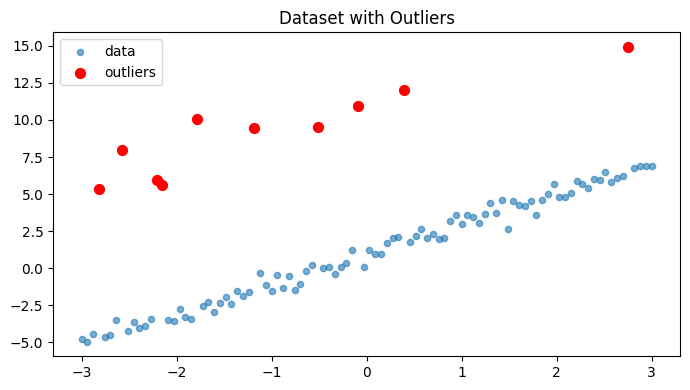

True parameters:  w=2.0,  b=1.0
Huber fit:        w=1.984, b=1.046
MSE fit:          w=1.649, b=1.982


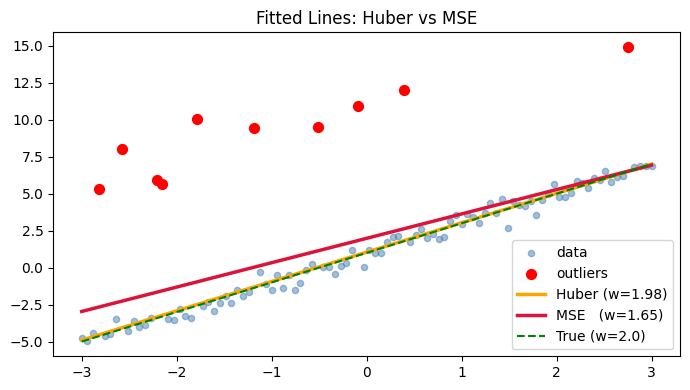

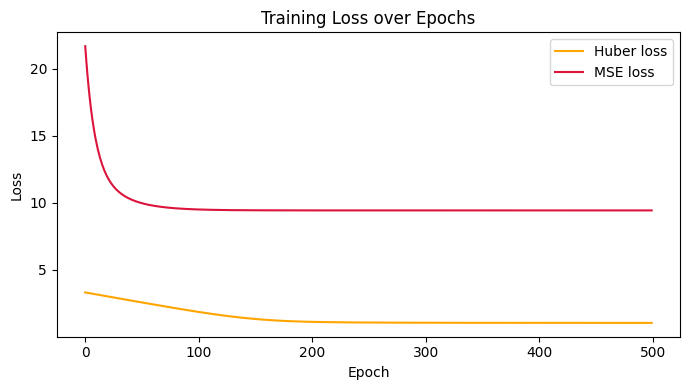

In [ ]:
# ============================================================
# Homework: Huber Loss & Gradient Descent for Linear Regression
# ============================================================
# Name: ___________________
#
# Goal: Implement gradient descent with Huber loss and see
#       how it resists outliers compared to MSE.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ── 0. Generate Data ────────────────────────────────────────
np.random.seed(42)
n = 100
X = np.linspace(-3, 3, n)
y_clean = 2 * X + 1 + np.random.randn(n) * 0.5   # true: w=2, b=1

# Add outliers: corrupt 10 random points
y = y_clean.copy()
outlier_idx = np.random.choice(n, size=10, replace=False)
y[outlier_idx] += np.random.uniform(8, 12, size=10)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=20, alpha=0.6, label='data')
plt.scatter(X[outlier_idx], y[outlier_idx], s=50, color='red', label='outliers')
plt.title("Dataset with Outliers")
plt.legend(); plt.tight_layout(); plt.show()


# ============================================================
# TASK 1 — Implement the Huber Loss                 (10 pts)
# ============================================================
# The Huber loss for a single residual r = y - y_hat is:
#
#   L(r) = 0.5 * r^2                    if |r| <= delta
#          delta * (|r| - 0.5 * delta)  if |r| >  delta
#
# Implement the MEAN Huber loss over all n samples.

def huber_loss(y, y_hat, delta):
    """
    Args:
        y      : true labels,    shape (n,)
        y_hat  : predictions,    shape (n,)
        delta  : threshold (float)
    Returns:
        scalar mean Huber loss
    """
    r = y - y_hat
    abs_r = np.abs(r)

    # Apply the piecewise formula across the whole array
    loss_elements = np.where(
        abs_r <= delta,
        0.5 * (r**2),                   # Quadratic part
        delta * (abs_r - 0.5 * delta)   # Linear part
    )

    return np.mean(loss_elements)


# ============================================================
# TASK 2 — Implement the Gradients                  (15 pts)
# ============================================================
# The gradient of the Huber loss w.r.t. w and b uses:
#
#   dL/dr = r              if |r| <= delta   (same as MSE)
#           delta*sign(r)  if |r| >  delta   (clipped — key to robustness!)
#
# Then by chain rule (r = y - wx - b):
#   dJ/dw = -(1/n) * sum( dL/dr_i * x_i )
#   dJ/db = -(1/n) * sum( dL/dr_i )

def huber_gradients(X, y, w, b, delta):
    """
    Args:
        X      : features,       shape (n,)
        y      : true labels,    shape (n,)
        w, b   : current parameters (floats)
        delta  : threshold (float)
    Returns:
        grad_w, grad_b  (floats)
    """
    r = y - (w * X + b)
    abs_r = np.abs(r)




    # Step 1: compute dL/dr for each sample (the "pseudo-residual")
    #   Use np.where or boolean masking to apply the piecewise rule
    # YOUR CODE HERE

    psi = np.where(
        abs_r <= delta,
        r,
        delta * np.sign(r)
    )



    # Step 2: compute grad_w and grad_b using the pseudo-residuals
    # YOUR CODE HERE

    grad_w = -np.mean(psi * X)
    grad_b = -np.mean(psi)

    return grad_w, grad_b


# ============================================================
# TASK 3 — Gradient Descent Loop                    (15 pts)
# ============================================================
# Implement the update rule:
#   w <- w - lr * grad_w
#   b <- b - lr * grad_b
# Run for n_epochs iterations, recording the loss each epoch.

def gradient_descent(X, y, delta, lr=0.01, n_epochs=500):
    """
    Returns:
        w, b         : learned parameters
        loss_history : list of loss values per epoch
    """
    w, b = 0.0, 0.0
    loss_history = []

    for epoch in range(n_epochs):

        y_hat = w * X + b

        loss = huber_loss(y, y_hat, delta)

        loss_history.append(loss)

        grad_w, grad_b = huber_gradients(X, y, w, b, delta)

        w = w - lr * grad_w

        b = b - lr * grad_b


    return w, b, loss_history


# ============================================================
# TASK 4 — MSE Gradient Descent (for comparison)    (5 pts)
# ============================================================
# Implement the same loop but for MSE loss.
# MSE gradient: dJ/dw = -(2/n)*sum(r*x),  dJ/db = -(2/n)*sum(r)

def mse_gradient_descent(X, y, lr=0.01, n_epochs=500):
    """
    Returns:
        w, b, loss_history
    """
    w, b = 0.0, 0.0
    loss_history = []
    n = len(y)

    for epoch in range(n_epochs):
        y_hat = w * X + b
        r = y - y_hat

        loss = np.mean(r**2)
        loss_history.append(loss)

        grad_w = -(2/n) * np.sum(r * X)
        grad_b = -(2/n) * np.sum(r)

        # Update
        w = w - lr * grad_w
        b = b - lr * grad_b

    return w,b,loss_history


# ============================================================
# Run & Compare
# ============================================================
w_hub, b_hub, loss_hub = gradient_descent(X, y, delta=1.0)
w_mse, b_mse, loss_mse = mse_gradient_descent(X, y)

print(f"True parameters:  w=2.0,  b=1.0")
print(f"Huber fit:        w={w_hub:.3f}, b={b_hub:.3f}")
print(f"MSE fit:          w={w_mse:.3f}, b={b_mse:.3f}")

# Plot 1: Fitted lines on data
plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=20, alpha=0.5, color='steelblue', label='data')
plt.scatter(X[outlier_idx], y[outlier_idx], s=50, color='red', label='outliers')
plt.plot(X, w_hub * X + b_hub, color='orange',  lw=2.5, label=f'Huber (w={w_hub:.2f})')
plt.plot(X, w_mse * X + b_mse, color='crimson', lw=2.5, label=f'MSE   (w={w_mse:.2f})')
plt.plot(X, 2 * X + 1,         color='green',   lw=1.5, linestyle='--', label='True (w=2.0)')
plt.title("Fitted Lines: Huber vs MSE")
plt.legend(); plt.tight_layout(); plt.show()

# Plot 2: Loss curves
plt.figure(figsize=(7, 4))
plt.plot(loss_hub, label='Huber loss', color='orange')
plt.plot(loss_mse, label='MSE loss',   color='crimson')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend(); plt.tight_layout(); plt.show()


# ============================================================
# TASK 5 — Analysis Questions                       (5 pts)
# ============================================================
# Answer in comments below:
#
# Q1. Look at the fitted lines plot. Which model's slope is closer
#     to the true value of 2.0? Why does this make sense given
#     how the two loss functions treat large residuals?
'''

The Huber fit yields a slope of approximately 1.984, while the MSE fit yields a slope of approximately 1.649.
The Huber model's slope (1.984)  is significantly closer to the true value (2.0) than the MSE model's slope (1.649).

This makes sense becuase The Huber lose uses quadratic penalty to a linear penalty for residuals larger than a specified
delta. This change of the penalty for large errors makes Huber loss much more robust to outliers,
preventing them from dominating the loss function and skewing the learned parameters as much as MSE'''

# YOUR ANSWER:
#

**Problem 2**

**Text as a sequence of words**

We need to distinguish two ways of talking about words. *Types* are the number of distinct words in a corpus; if the set of words in the vocabulary is $V$, the number of types is the vocabulary size $|V|$. *Tokens* are the total number $N$ of running words.

The larger the corpora we look at, the more word types we find. This relationship between the number of types $|V|$ and number of tokens $N$ is called **Herdan's Law** (Herdan, 1960) or **Heaps' Law** (Heaps, 1978). It is given by:

$$|V| = k N^{\beta}$$

where $k$ and $\beta$ are positive constants with $0 < \beta < 1$. Our objective is to test whether this relationship holds empirically across the 18 texts in the NLTK Gutenberg corpus.

The starter code is provided below. The sections you must complete are marked `## YOUR CODE BEGINS / ENDS`. Note that the code uses `.lower()`.

**Part 1** — complete the following using the version *with* `.lower()`:

- Initialize two lists to collect $N$ and $|V|$ for each text, and append to them inside the loop.
- Plot a scatter plot of $|V|$ vs $N$.
- Take $\log$ of both sides of $|V| = kN^\beta$ to obtain the linear equation $\log|V| = \log k + \beta \log N$. Use this to formulate the estimation of $\log k$ and $\beta$ as a simple linear regression problem. Run the regression and print the estimates.
- Make a scatter plot in log-scale and include the fitted regression line. The plot should display the estimated equation.
- Compute the 95% confidence interval for $\beta$ and state whether your result confirms or rejects Herdan's Law.

**Part 2** — remove `.lower()` from the code and repeat Part 1. Specifically:

- What is the function of `.lower()`?
- Repeat all steps from Part 1 without `.lower()`.
- Compare the estimated $\beta$ and $k$ with Part 1 and comment on the difference in relation to Herdan's Law.

**Part 3** — implement Huber regression using gradient descent (as in Problem 1) on the log-scale data, and compare the estimated slope $\beta$ with the OLS estimates from Parts 1 and 2.

**Hint.** You may find the following useful: https://www.nltk.org/book

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


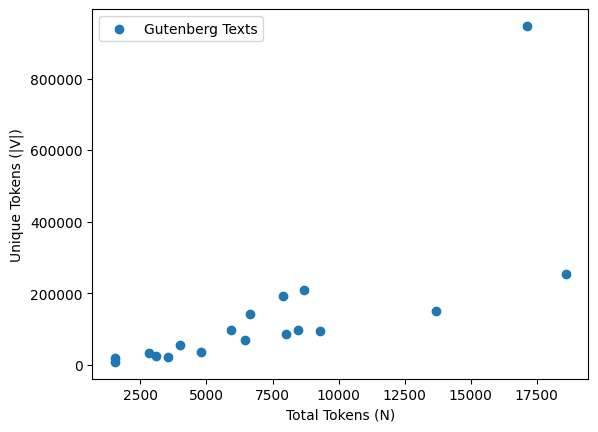

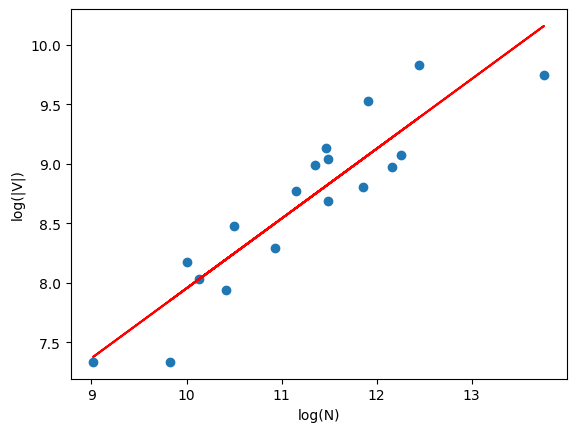

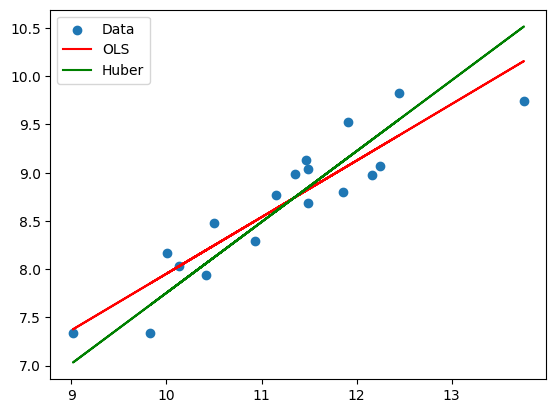

In [20]:
import nltk
from nltk.tokenize import word_tokenize
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, sys

# This blocks the "Downloading..." and "Already up-to-date" text
sys.stdout = open(os.devnull, 'w')
sys.stderr = open(os.devnull, 'w')

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('gutenberg')

from nltk.corpus import gutenberg

# ============================================================
# PART 1 — With .lower()
# ============================================================

## YOUR CODE BEGINS - initialize two lists to store N and |V| across texts

N_list = []
V_list = []

## YOUR CODE ENDS

for fileid in gutenberg.fileids():
    raw_text = gutenberg.raw(fileid).lower()
    tokens = word_tokenize(raw_text)
    unique_tokens = len(set(tokens))
    title = fileid
    length = len(tokens)

    ## YOUR CODE BEGINS - append length and unique_tokens to your lists

    N_list.append(length)
    V_list.append(unique_tokens)

    ## YOUR CODE ENDS

    print(f"Title: {title}")
    print(f"Number of unique tokens: {unique_tokens}")
    print(f"Length of work: {length}")
    print()

N_arr = np.array(N_list)
V_arr = np.array(V_list)

## YOUR CODE BEGINS

# 1. Scatter plot of |V| vs N

plt.scatter(V_arr, N_arr,label='Gutenberg Texts')
plt.xlabel("Total Tokens (N)")
plt.ylabel("Unique Tokens (|V|)")
plt.legend()
plt.show()

## YOUR CODE ENDS

## YOUR CODE BEGINS

# 2. Take the log of both sides of |V| = k * N^beta to get a linear equation.
#    Run a simple linear regression on log|V| vs log(N) using stats.linregress.
#    Print the estimated beta, log(k), k, and R².

log_N = np.log(N_arr)
log_V = np.log(V_arr)

res = stats.linregress(log_N, log_V)
beta, log_k = res.slope, res.intercept
k = np.exp(log_k)
r_squared = res.rvalue**2

print("beta",beta)
print("Logk",log_k)
print("k",k)
print("R²",r_squared)

## YOUR CODE ENDS

## YOUR CODE BEGINS

# 3. Compute the 95% confidence interval for beta using the t-distribution.
#    Print the interval and state whether it confirms Herdan's Law (0 < beta < 1).

df = len(N_arr) - 2
t_val = stats.t.ppf(0.975, df)
moe = t_val * res.stderr
ci = (beta - moe, beta + moe)

print(f"95% CI for Beta: {ci}")
print(f"Confirms Herdan's Law (0 < beta < 1): {0 < beta < 1}")

## YOUR CODE ENDS

## YOUR CODE BEGINS

# 4. Scatter plot in log-scale with the estimated regression line.
#    Include the estimated equation in the legend.

plt.scatter(log_N, log_V, label='Original Data')
plt.plot(log_N, log_k + beta * log_N, 'r', label=f'log|V| = {beta:.2f}logN + {log_k:.2f}')
plt.xlabel("log(N)")
plt.ylabel("log(|V|)")
plt.show()

## YOUR CODE ENDS

# ============================================================
# PART 2 — Without .lower()
# ============================================================

# Q: What is the function of .lower()?
## YOUR ANSWER HERE (as a comment):
## converts all characters to lowercase.

## YOUR CODE BEGINS
# Repeat all steps from Part 1 with .lower() removed from the raw_text line.
# Then print a side-by-side comparison of beta and k from both parts
# and comment on the difference in relation to Herdan's Law.

N_list_raw, V_list_raw = [], []

for fileid in gutenberg.fileids():
    raw_text = gutenberg.raw(fileid) # Removed .lower()
    tokens = word_tokenize(raw_text)
    N_list_raw.append(len(tokens))
    V_list_raw.append(len(set(tokens)))

log_N_raw = np.log(np.array(N_list_raw))
log_V_raw = np.log(np.array(V_list_raw))

res_raw = stats.linregress(log_N_raw, log_V_raw)
beta_raw, log_k_raw = res_raw.slope, res_raw.intercept

print(f"Part 2 (No Lower) - Beta: {beta_raw:.3f}, k: {np.exp(log_k_raw):.3f}")

## YOUR CODE ENDS

# ============================================================
# PART 3 — Huber Regression (log scale)
# ============================================================
# Apply Huber regression to the log-scale data (log N → log |V|).
# Use gradient descent as implemented in the Huber Loss homework.
# Compare the estimated slope (beta) with the OLS estimates from Parts 1 and 2.

def huber_loss(y, y_hat, delta):

    ## YOUR CODE BEGINS

    r = y - y_hat
    abs_r = np.abs(r)
    # Piecewise formula: Quadratic if small, Linear if large

    loss = np.where(
        abs_r <= delta,
        0.5 * r**2,
        delta * (abs_r - 0.5 * delta)
        )
    return np.mean(loss)

    ## YOUR CODE ENDS

def huber_gradients(X, y, w, b, delta):
    y_hat = w * X + b
    r = y - y_hat
    abs_r = np.abs(r)

    # Derivative of Huber Loss w.r.t y_hat

    d_yhat = np.where(abs_r <= delta, -r, -delta * np.sign(r))
    dw = np.mean(d_yhat * X)
    db = np.mean(d_yhat)
    return dw, db

def huber_gd(X, y, delta=1.0, lr=0.01, n_epochs=2000):

    w, b = 0.0, 0.0

    for _ in range(n_epochs):

        dw, db = huber_gradients(X, y, w, b, delta)
        w -= lr * dw
        b -= lr * db
    return w, b

    ## YOUR CODE ENDS

## YOUR CODE BEGINS

# Fit Huber regression on the log-scale data from Part 1.
# Plot OLS and Huber regression lines on the same log-scale scatter plot.
# Print a final comparison table of beta and k for all three cases:
#   OLS with .lower(), OLS without .lower(), Huber with .lower()

beta_huber, logk_huber = huber_gd(log_N, log_V)

# Plotting
plt.scatter(log_N, log_V, label='Data')
plt.plot(log_N, log_k + beta * log_N, color='red', label='OLS')
plt.plot(log_N, logk_huber + beta_huber * log_N, color='green', label='Huber')
plt.legend()
plt.show()

# Final Comparison Prints
print("OLS (with lower) - Beta:", beta, "k:", np.exp(log_k))
print("OLS (no lower)   - Beta:", beta_raw, "k:", np.exp(log_k_raw))
print("Huber (with lower)- Beta:", beta_huber, "k:", np.exp(logk_huber))

## YOUR CODE ENDS

# **Problem 3**

## Sentiment Classification: Bag of Words & Logistic Regression

### The Data

The IMDB dataset contains 50,000 movie reviews, each labeled as positive ($y=1$) or negative ($y=0$). Our goal is to train a classifier that predicts sentiment from the text of a review.

---

### Bag of Words

To apply a statistical model to text we first need to convert each review into a numeric vector. The **bag-of-words** representation does this by fixing a vocabulary $V = \{w_1, w_2, \ldots, w_p\}$ of the $p$ most frequent words, then representing each review as a count vector $\mathbf{x} \in \mathbb{R}^p$ where

$$x_j = \text{number of times word } w_j \text{ appears in the review.}$$

Word order is ignored — the review is treated as an unordered *bag* of words. For example, the vocabulary $V = \{\text{good, bad, film, not}\}$ would encode the review *"not a good film"* as $\mathbf{x} = (1, 0, 1, 1)$.

We use `CountVectorizer` from scikit-learn to build this representation. It is important to **fit the vectorizer on the training set only**, then apply the same vocabulary to the test set — otherwise information from the test set leaks into the feature construction.

---

### Logistic Regression

Given the feature vector $\mathbf{x}$ for a review, logistic regression models the probability of positive sentiment as:

$$P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

where $\sigma$ is the sigmoid function and $\mathbf{w} \in \mathbb{R}^p$, $b \in \mathbb{R}$ are the parameters to learn.

The parameters are found by minimizing the **cross-entropy loss** (also called log-loss) over the training set:

$$\widehat R(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \widehat{p}_i + (1 - y_i) \log (1 - \widehat{p}_i) \right]$$

where $\widehat{p}_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$. This loss is convex and differentiable, so it can be minimized with gradient descent. The gradient with respect to $\mathbf{w}$ is:

$$\nabla_{\mathbf{w}} \widehat R = \frac{1}{n} \sum_{i=1}^{n} (\widehat{p}_i - y_i)\, \mathbf{x}_i$$

which has the same intuitive form as the regression gradients from the previous problems: it is the prediction error $(\widehat{p}_i - y_i)$ weighted by the input $\mathbf{x}_i$, and the update $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_\mathbf{w} \widehat R$ pushes the parameters in the direction that reduces the loss.

In scikit-learn, `LogisticRegression` handles the minimization internally using an efficient solver, but the objective it minimizes is exactly $\widehat R$ above plus an optional regularization term $\frac{1}{2C}\|\mathbf{w}\|^2$ controlled by the hyperparameter `C`. Larger `C` means less regularization. Use $C=1$.

---

### ROC Curve and AUC

Rather than reporting accuracy at a single threshold, the **ROC curve** traces out the trade-off between the True Positive Rate and the False Positive Rate as the classification threshold varies from 0 to 1. The **AUC** (area under the curve) summarizes this in a single number: a perfect classifier has AUC $= 1$, and a random classifier has AUC $= 0.5$.

---

### Your Tasks

The starter code downloads the data automatically. The sections you must complete are marked `## YOUR CODE BEGINS / ENDS`.

- Build the bag-of-words matrix using `CountVectorizer` with the 10,000 most frequent words. Fit on train only, then transform both train and test.
- Train `LogisticRegression(max_iter=1000)` and report the **train error** and **test error** (error $= 1 -$ accuracy).
- Plot the **ROC curve** on the test set and report the **AUC**.

Answer the three analysis questions at the bottom as comments in the code.

Training samples : 25000
Test samples     : 25000


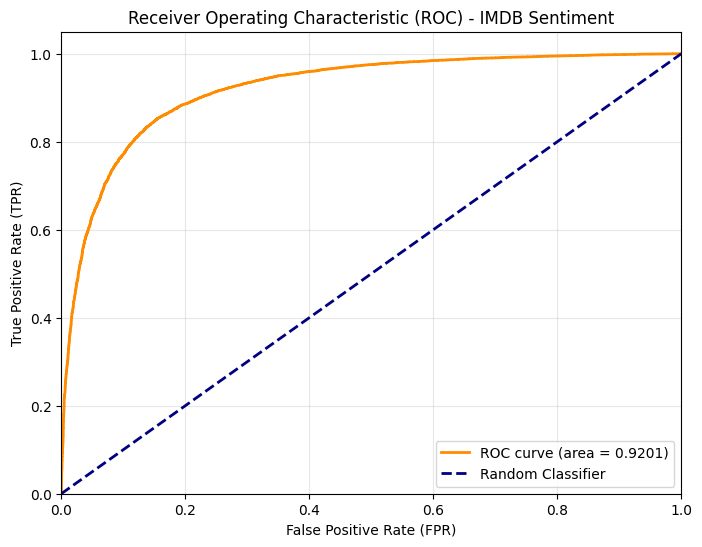

Test AUC: 0.9201


In [10]:
import urllib.request
import tarfile
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,  auc, accuracy_score

# ── 0. Download & Load Data ───────────────────────────────────
if not os.path.exists("aclImdb"):
    print("Downloading IMDB dataset (~84MB)...")
    urllib.request.urlretrieve(
        "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
        "aclImdb_v1.tar.gz"
    )
    tarfile.open("aclImdb_v1.tar.gz").extractall()
    print("Done.")

train_data = load_files("aclImdb/train", categories=["pos", "neg"],
                        encoding="utf-8", decode_error="replace")
test_data  = load_files("aclImdb/test",  categories=["pos", "neg"],
                        encoding="utf-8", decode_error="replace")

X_train_raw, y_train = train_data.data, train_data.target
X_test_raw,  y_test  = test_data.data,  test_data.target

print(f"Training samples : {len(y_train)}")
print(f"Test samples     : {len(y_test)}")


## YOUR CODE BEGINS
# 1. Use CountVectorizer with max_features=10_000 and stop_words="english"
#    to convert the raw text into a bag-of-words matrix.
#    Fit on the training set only; apply the same vocabulary to the test set.

vector = CountVectorizer(max_features=10_000, stop_words="english")
X_train = vector.fit_transform(X_train_raw)
X_test = vector.transform(X_test_raw)

## YOUR CODE ENDS


## YOUR CODE BEGINS
# 2. Train a LogisticRegression classifier (max_iter=1000) on the training data.

log_reg = LogisticRegression(max_iter=1000, C= 1.0)
log_reg.fit(X_train, y_train)

## YOUR CODE ENDS

# 3. Compute and print the train error and test error (error = 1 - accuracy).

train_preds = log_reg.predict(X_train)
test_preds = log_reg.predict(X_test)

train_error = 1 - accuracy_score(y_train, train_preds)
test_error = 1 - accuracy_score(y_test, test_preds)

## YOUR CODE ENDS


## YOUR CODE BEGINS

# 4. Plot the ROC curve on the test set.
#    Use clf.predict_proba to get probability scores for the positive class.
#    Include the AUC value in the legend.
#    Add a dashed diagonal line for the random classifier baseline.

y_probs = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - IMDB Sentiment')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Test AUC: {roc_auc:.4f}")

## YOUR CODE ENDS
# ============================================================
# Analysis Questions
# ============================================================
# Q1. Is there a large gap between train and test error?
#     What does this tell you about overfitting?

 '''Yes, there is a large gap. The training error is approximately 0.0098.
  while the test error is approximately 0.1526. This means that the model is overfitting.

Meaning that he model has learned the training examples and specific patterns
but it struggles to generalize to new unseen data.'''

#
# Q2. What does the AUC measure, and why is it more informative
#     than accuracy alone for this task?

'''Auc or Area Under the ROC Curve) measures the model's ability to rank a random positive sample
 higher than a random negative sample across all possible classification thresholds. Accuracy provides
 a single performance metric at a specific decision threshold.

It is more informative than accuracy because accuracy only tells us how the model performs at a
single cutoffb .'''
#
# Q3. Bag-of-words ignores word order. Give one example where
#     this would cause the model to misclassify a review.

'''Since bag of words ignores the word order it cannot handle negation or sarcasm effectively.
It might casue the modle to misclassify a review being good when it was bad and bad when it was good.
A example of this might be saying "the move was not that bad or this movie was bad and not good at all'''

